# POS tagging and context readning

## Find most common POS tags in keyword sentences

Part of Speech (POS) tags are labels assigned to words in a text to indicate their grammatical category. Common categories is for example nouns, verbs, adjectives and so on. In digital text analysis we can use POS tags to provide context about a keyword being analyzed.

Here we will use the Python library [jieba](https://github.com/fxsjy/jieba) to assign POS labels to our texts.

Jieba can assign the following labels:<br><br><br>




| Tag  | Meaning                    | Tag  | Meaning                    | Tag  | Meaning                    | Tag  | Meaning                    |
|------|----------------------------|------|----------------------------|------|----------------------------|------|----------------------------|
| n    | Common noun                | PER  | Personal name              | m    | Quantifier                 | a    | Adjective                  |
| f    | Locative noun              | LOC  | Geographical name          | q    | Measure word               | ad   | Adverbial adjective        |
| s    | Place noun                 | ORG  | Organization name          | r    | Pronoun                    | an   | Nominal adjective          |
| t    | Time                       | TIME | Time                       | p    | Preposition                | d    | Adverb                     |
| nr   | Personal name              |      |                            | c    | Conjunction                |      |                            |
| ns   | Geographical name          |      |                            | u    | Auxiliary word             |      |                            |
| nt   | Organization name          |      |                            | xc   | Other functional words      |      |                            |
| nw   | Work name                  |      |                            | w    | Punctuation                |      |                            |
| nz   | Other proper nouns         |      |                            |      |                            |      |                            |
| v    | Common verb                |      |                            |      |                            |      |                            |
| vd   | Verbal adverb              |      |                            |      |                            |      |                            |
| vn   | Nominal verb               |      |                            |      |                            |      |                            |

<br><br><br>

Source: https://github.com/fxsjy/jieba


In the script below you can choose a keyword, time periode, and a tag representing a POS category.

The script then extracts the sententence that holds the keywords and visualise the most common words within the POS category that you choose.  

Building prefix dict from C:\Users\lakj\AppData\Local\anaconda3\envs\langchain_python_v_3_9_21\lib\site-packages\jieba\dict.txt ...
Dumping model to file cache C:\Users\lakj\AppData\Local\Temp\jieba.cache
Loading model cost 0.9869985580444336 seconds.
Prefix dict has been built succesfully.


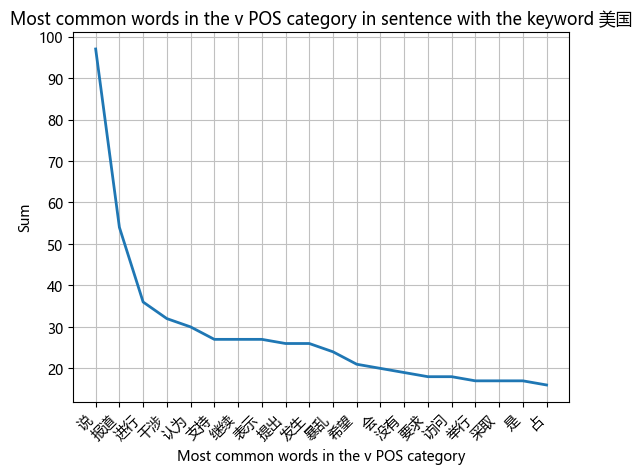

In [2]:
# Get the data out from the database into a dataframe
import sqlite3
import pandas as pd

conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()


# Choose keyword, time period and a POS Tag for example 'v', 'n', 'a'

keyword = '美国'
time_from = '1989-06-01'
time_to = '1989-06-31'
part_of_speech_tag = 'v'


# Extract articles with in time period
# Use f-strings and add keyword, time from, and time to search where keyword is in the content
c.execute(f"SELECT * FROM rmrb WHERE content LIKE '%{keyword}%' AND (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")

# Send the data to a dataframe
df = pd.DataFrame(c.fetchall()) 
# rename columns
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})


# Find most common pos tags in keyword sentences
# iterate the dataframe, split the content into sentences, 
# search for the keyword in the sentences, 
# and add to a list the sentences that holds the keyword 
keyword_sentences = [] # empty list to store sentences that holds the keyword
for index, row in df.iterrows():
    content = row['Content']
    
    text_sentences_list = content.split("。") # split content into sentences

    for sentence in text_sentences_list: # iterate the lsit of sentences 
        if keyword in sentence: # check if the keyword is in the sentence
            keyword_sentences.append(sentence) # append the keyword to empty list

# join the list of sentences into a text string 
keyword_text = ' '.join(keyword_sentences)



# remove stopwords from the keyword_text string
# we load a stop word list. It is online at Science data. 
from urllib.request import urlopen
import jieba_next as jieba
target_url = 'https://sciencedata.dk/shared/93a217a0533d949d9b2c675cd3c99cfd?download'
sw_ch = urlopen(target_url).read().decode('utf-8').split()
filtered_tokens = [] # Empty list to store words that isn't stopwords
for word in jieba.lcut(keyword_text, cut_all=False):
    if word not in sw_ch:
        filtered_tokens.append(word)

# join the filtered text (the text with out stopwords) into a text string
filtered_text = ' '.join(filtered_tokens)


# import library, tokenize, and pos tag text
import jieba.posseg as pseg
tokens_with_tags = pseg.cut(filtered_text)
pos_tags = []
for w in tokens_with_tags:
    if w.word > ' ':
        word_tag = tuple((w.word, w.flag))
        pos_tags.append(word_tag)

words = []
for item in pos_tags:
    if item[1] == part_of_speech_tag: # incert the part of speech tag
        words.append(item[0])

# Import libraries
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Microsoft YaHei"  # husk på mac skal man bruge  'Heiti TC'

import nltk
nltk.FreqDist(words).plot(20)
most_common_words = nltk.FreqDist(words)


# Customize the axis labels
plt.ylabel('Sum')  # Set your custom x-axis label
plt.xlabel(f'Most common words in the {part_of_speech_tag} POS category')  # Set your custom y-axis label


# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')


# Optionally, set a title for the plot
plt.title(f'Most common words in the {part_of_speech_tag} POS category in sentence with the keyword {keyword}')

# save image
# use f-string and add the pos tag, keyword and time to the file name
plt.savefig(fr'./out/most common words in the {part_of_speech_tag} POS category in sentence with the keyword {keyword}_{time_from}_{time_to}_plot.png', bbox_inches='tight')


# Show the plot with the custom labels
plt.show()


## Extract articles with keyword and time period

In the script below we extract articles from the database that holds a choosen keyword and we also add a time period to limit our extraction. 

All the articles are stored as txt files in a folder called "articles". From here you can import them into software like Voyant or Orange. The articles is also stored into a list and can be printed in the script. Below we only print the first three articles from the list, but this can be changed. When printing the articles in the script the keyword is highlighted with red.


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()


# Extract articles with keyword in time period
keyword = '美国'
time_from = '1989-06-01'
time_to = '1989-06-31'

# use f-strings and add keyword, time from, and time to 
c.execute(f"SELECT * FROM rmrb WHERE content LIKE '%{keyword}%' AND (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
df = pd.DataFrame(c.fetchall())

# rename columns
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})


# Iterate over the DataFrame rows using iterrows()
# Add each article to the list of articles 
# Save each article in ./out/articles

articles = []

for index, row in df.iterrows():
    date    = row['Date'].replace('-', '_')
    section = row['Section']
    heading = row['Heading']
    content = row['Content']
    page =    row['Page']

    # put together a file name 
    file_name = date + '_' + keyword + '_' + heading

    # put together the text content
    text = section +  '\n' + page + '\n' + heading + '\n' + content

    # add date and text to the list of articles (the new lines and stars is to make the printed output more readable) 
    article = date + '\n' + text + '\n' + '*' * 50 + '\n'
    articles.append(article) 

    # use open to make a file with the file name and store the text into it
    with open(fr'./out/articles/{file_name}.txt', 'w', encoding='utf-8') as f:
        f.write(text)

# print the first three articles
for i in articles[0:3]:
    print (i.replace(f'{keyword}', f'\033[1m\033[31m{keyword}\033[39m\033[0m'))

1989_06_02
第1版(要闻)
1
认清动乱的实质和戒严的必要性
    中共北京市委宣传部
    ４月２６日《人民日报》社论和５月１９日李鹏同志代表党中央、国务院所作的重要讲话，都十分明确地提出，要旗帜鲜明地反对动乱，制止动乱。为此，国务院于５月２０日发布了在北京市部分地区实行戒严的命令，派部分军队到北京来和武警部队、公安干警以及广大群众、青年学生一道，维护首都社会治安，恢复首都正常的生产、工作、教学、科研和生活秩序。
    但是，不少群众和学生对此还不很理解，思想上还有一些“扣”没有解开。有人认为，既然学生是爱国的，为什么又说发生了动乱？既然学生是爱国的，为什么又要派解放军来？说到底，还是对这场政治斗争的严重性以及戒严的必要性认识不足。因此，有必要把实际情况向广大群众和青年学生解释清楚。
    一、为什么说北京发生了严重的动乱？
    首先要说的是，党和政府一直对广大青年学生的爱国热情给予了充分的肯定，从来没有说过广大学生是在搞动乱。４月２６日《人民日报》社论，李鹏同志代表党中央、国务院所作的讲话，徐向前元帅、聂荣臻元帅的讲话和邓颖超同志的信，陈云同志在中顾委常委会上的讲话，李先念同志在全国政协主席会议上的讲话，彭真同志在部分民主党派负责人座谈会上的讲话，万里同志的书面谈话，都反复地、明确地指出，广大青年学生在推进民主、清除腐败、整治“官倒”、克服官僚主义等方面提出的要求，同党和政府的愿望是一致的，并对促进这些问题的解决起到了积极的作用。这就充分说明，党和政府从来没有说过广大学生在搞动乱。同时，又总是把极少数人制造动乱的阴谋活动，同青年学生的爱国热情严格区别开来。
    那么，极少数人到底是怎样利用广大青年学生的善良愿望，利用一些人的思想混乱，利用党和政府的某些失误，以及前进中遇到的困难，来制造动乱的呢？大家看一看近一个时期以来发生的一系列极不正常的情况，就不难做出正确的结论。
    第一，极少数人制造动乱是早有预谋的。
    早在去年年底和今年年初，极少数人就在一些高校内外密谋策划，要借“五四”７０周年、建国４０周年、法国大革命２００周年的时机，煽起学潮，挑起事端。
    今年３月初在北大、清华等高校相继发现了一些没有署名的大小字报，直接攻击党的领导，攻击社会主义制度。一份题为《为中国人悲哀》的小字报说，现在的政府是“独裁专制”，号召大家

## Context tool

The script below is a "Context tool". You can use the tool to explore the context surrounding the keyword. This is useful for qualitative reading and can provide a new path into the texts, where you do not begin reading from the start, but read the sentences where the keyword apears. The keyword is highlighted in red.


In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()

# Extract articles with keyword in time period
keyword = '美国'
time_from = '1989-06-01'
time_to = '1989-06-10'

# use f-strings and add keyword, time from, and time to 
c.execute(f"SELECT * FROM rmrb WHERE content LIKE '%{keyword}%' AND (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
df = pd.DataFrame(c.fetchall())

# rename columns
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})

for i in range(len(df)):
    print("Date:  " + df['Date'][i]) # iteration indsætter index tallet og printer værdien  
    print("Heading:  " + df['Heading'][i]) # iteration indsætter index tallet og printer værdien
    text_sentences_list = df['Content'][i].split("。") # iteration indsætter index tallet og splitter t
                                                        # ekststreng vha. split metoden. returnere en liste.
    for idx,sentence in enumerate(text_sentences_list): # itererer ny liste. 
        if keyword in sentence: # indsætter betingelse; hvis keyword er i sætning, så print
            print("line", idx, ":", sentence.strip().replace(f'{keyword}', f'\033[1m\033[31m{keyword}\033[39m\033[0m'))
    print("\n\n") # printer to tomme linjer


Date:  1989-06-02
Heading:  认清动乱的实质和戒严的必要性
line 52 : 反动组织“中国民主联盟”成员胡平、陈军等人，联名于４月２２日从美国纽约发出《致中国大学生公开信》，在北京高校中张贴，要学潮的组织者注意“巩固在这次活动中建立起来的组织联系，力求以一个坚强的群体进行有效的活动”，目前“应把彻底否定１９８７年反自由化运动作为突破口”，“加强与各种新闻媒介的联系”，“加强与社会其它各界的联系，……在运动中争取他们的支持和参与”
line 54 : 一批身居美国的原《中国之春》成员，组成了“中国民主党”，于４月１６日向北京一些大学发出《告全国同胞书》，煽动学生“要求保守派官僚们下台”，“促使中共结束其专制统治”



Date:  1989-06-02
Heading:  涂鸦
line 39 : 第一句是苏联列宁说的，第二句是美国肯尼迪说的，第三句是中国李大钊说的，第四句是希腊亚里斯多德说的，第五句是Ｊ·Ｐ·逊说的，最后一句才是我说的



Date:  1989-06-02
Heading:  图片
line 1 : 据多数人认为，这幅科西莫·德梅迪奇公爵肖像画（又名《戟兵》），是美国私人珍藏的最好一幅18世纪前的名家之作



Date:  1989-06-02
Heading:  国家旅游局发言人发表谈话  来华游览活动可正常进行  国旅总社总经理说旅游者人身安全未受侵犯
line 8 : 正在中国旅游的美国哈里斯旅行社领队苏林日前在北京对一位外国记者说：“现在来中国旅游没什么妨碍



Date:  1989-06-02
Heading:  我外商投资企业激增  近１０年兴建１．５万多家
line 4 : 特别是近两年来，美国、日本两国投资激增，投资额已占全国协议外资金额的３０％以上；台湾厂商来大陆投资的也明显增加，去年协议资金额已达６亿美元



Date:  1989-06-02
Heading:  萨尔瓦多新总统宣誓就职  表示以法制原则治理国家
line 10 : 另一方面，美国多年扶植的“中间力量”大选败北，对于在人权方面有不光彩纪录的极右派执政，也抱有疑虑



Date:  1989-06-02
Heading:  西德总理就北约首脑会议发表政府声明  会议取得重要成果  支持苏欧改革进程
line 4 : 对于

In [5]:
df['Date'][1]

'1989-06-02'

In [6]:
df['Content'][0].split("。")

['    中共北京市委宣传部\n    ４月２６日《人民日报》社论和５月１９日李鹏同志代表党中央、国务院所作的重要讲话，都十分明确地提出，要旗帜鲜明地反对动乱，制止动乱',
 '为此，国务院于５月２０日发布了在北京市部分地区实行戒严的命令，派部分军队到北京来和武警部队、公安干警以及广大群众、青年学生一道，维护首都社会治安，恢复首都正常的生产、工作、教学、科研和生活秩序',
 '\n    但是，不少群众和学生对此还不很理解，思想上还有一些“扣”没有解开',
 '有人认为，既然学生是爱国的，为什么又说发生了动乱？既然学生是爱国的，为什么又要派解放军来？说到底，还是对这场政治斗争的严重性以及戒严的必要性认识不足',
 '因此，有必要把实际情况向广大群众和青年学生解释清楚',
 '\n    一、为什么说北京发生了严重的动乱？\n    首先要说的是，党和政府一直对广大青年学生的爱国热情给予了充分的肯定，从来没有说过广大学生是在搞动乱',
 '４月２６日《人民日报》社论，李鹏同志代表党中央、国务院所作的讲话，徐向前元帅、聂荣臻元帅的讲话和邓颖超同志的信，陈云同志在中顾委常委会上的讲话，李先念同志在全国政协主席会议上的讲话，彭真同志在部分民主党派负责人座谈会上的讲话，万里同志的书面谈话，都反复地、明确地指出，广大青年学生在推进民主、清除腐败、整治“官倒”、克服官僚主义等方面提出的要求，同党和政府的愿望是一致的，并对促进这些问题的解决起到了积极的作用',
 '这就充分说明，党和政府从来没有说过广大学生在搞动乱',
 '同时，又总是把极少数人制造动乱的阴谋活动，同青年学生的爱国热情严格区别开来',
 '\n    那么，极少数人到底是怎样利用广大青年学生的善良愿望，利用一些人的思想混乱，利用党和政府的某些失误，以及前进中遇到的困难，来制造动乱的呢？大家看一看近一个时期以来发生的一系列极不正常的情况，就不难做出正确的结论',
 '\n    第一，极少数人制造动乱是早有预谋的',
 '\n    早在去年年底和今年年初，极少数人就在一些高校内外密谋策划，要借“五四”７０周年、建国４０周年、法国大革命２００周年的时机，煽起学潮，挑起事端',
 '\n    今年３月初在北大、清华等高校相继发现了一些没有署名的大小字报，直接攻击党的领导，攻击社会主义制度',
 '一份题为《为中国人